In [1]:
import torch
from analysis import find_kway_collisions
from tqdm import tqdm

In [2]:
ns = torch.tensor([2,3,4])
ms = torch.tensor([4, 5, 6, 7, 8])

N_samples = 200

In [5]:
stats = {}

for n in ns:
    for m in ms[ms>n+1]:
        stats[(n.item(),m.item())] = []

for n in ns:
    for m in ms[ms>n+1]:
        print(n.item(), m.item())
        for _ in tqdm(range(N_samples)):
            A = 1 - 2*torch.rand(m, n)
            b = 1 - 2*torch.rand(m)
            B = 1 - 2*torch.rand(n, m)
            collapses = find_kway_collisions(A, b, B, alpha_check=1, pairs=True, cache=False, verbose=False)
            stats[(n.item(),m.item())].append(collapses)

2 4


100%|██████████| 200/200 [00:47<00:00,  4.20it/s]


2 5


100%|██████████| 200/200 [01:10<00:00,  2.82it/s]


2 6


...

100%|██████████| 200/200 [05:08<00:00,  1.54s/it]


4 7


100%|██████████| 200/200 [10:56<00:00,  3.28s/it]


4 8


100%|██████████| 200/200 [22:07<00:00,  6.64s/it]


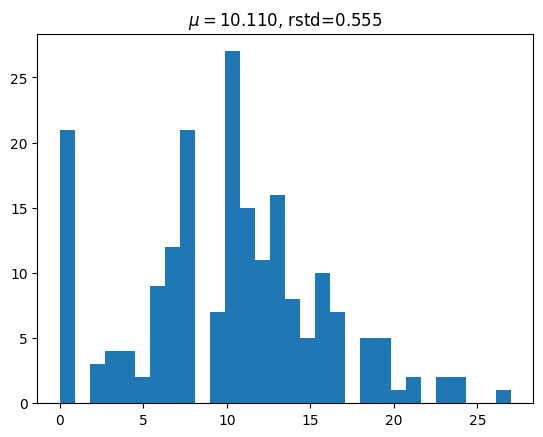

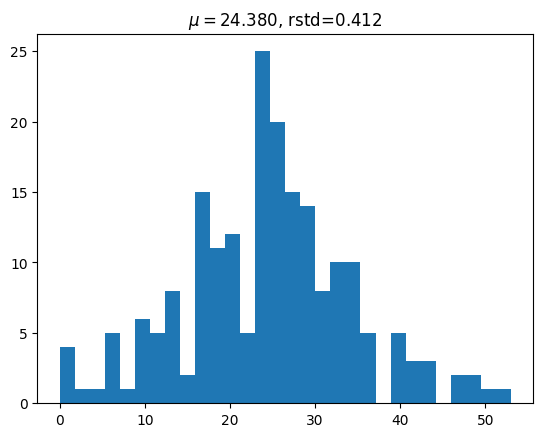

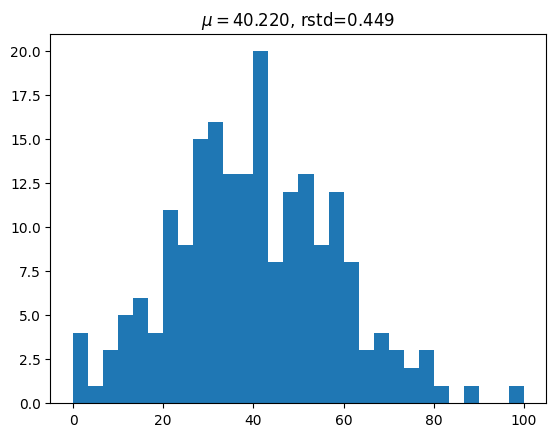

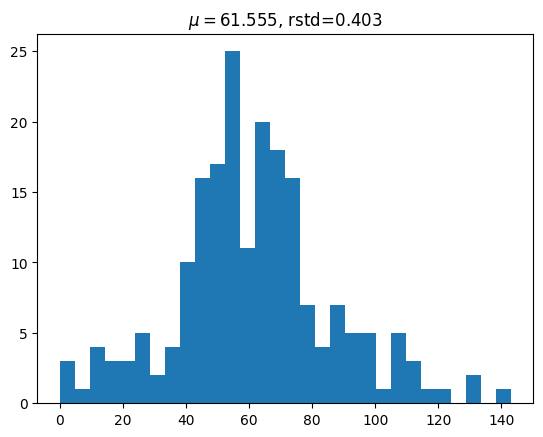

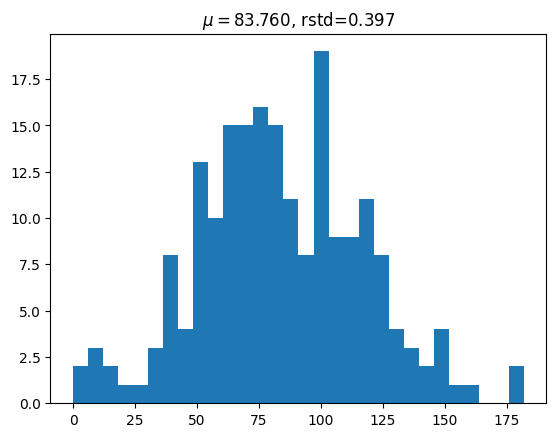

In [6]:
import matplotlib.pyplot as plt

n = 2
for m in ms[ms>n+1]:
    fig, ax = plt.subplots()
    collapses = torch.tensor(stats[(n, m.item())])
    ax.hist(stats[(n, m.item())], bins=30)
    collapses = collapses.to(float)
    ax.set_title(f"{r'$\mu=$'}{collapses.mean().item():.3f}, rstd={(collapses.std()/collapses.mean()).item():.3f}")
plt.show()

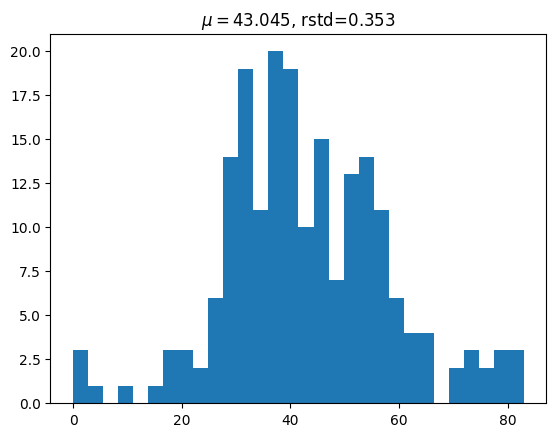

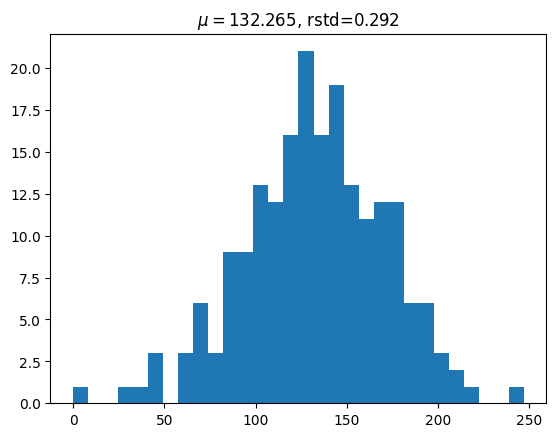

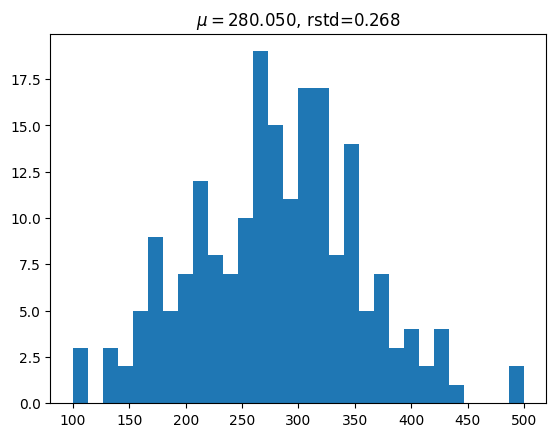

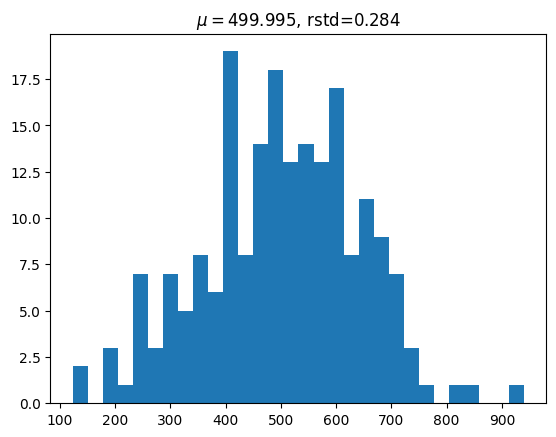

In [8]:
n = 3
for m in ms[ms>n+1]:
    fig, ax = plt.subplots()
    collapses = torch.tensor(stats[(n, m.item())])
    ax.hist(stats[(n, m.item())], bins=30)
    collapses = collapses.to(float)
    ax.set_title(f"{r'$\mu=$'}{collapses.mean().item():.3f}, rstd={(collapses.std()/collapses.mean()).item():.3f}")
plt.show()

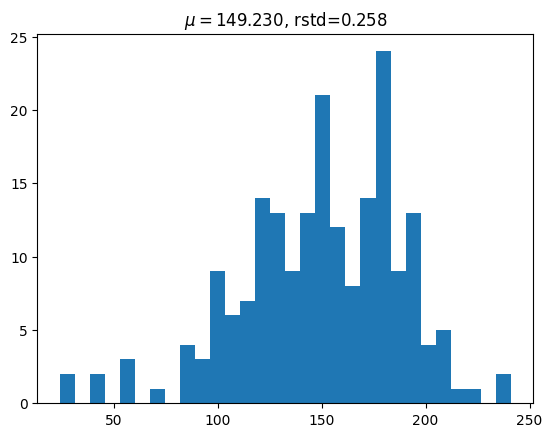

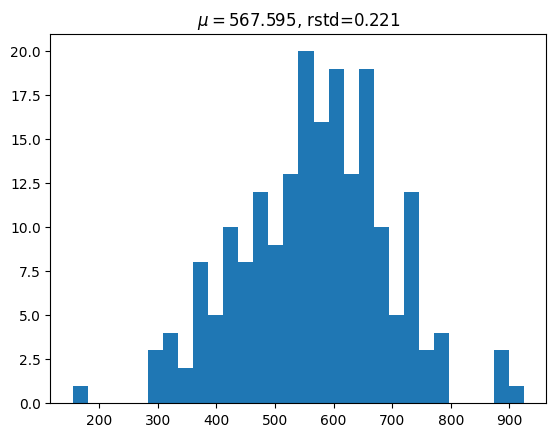

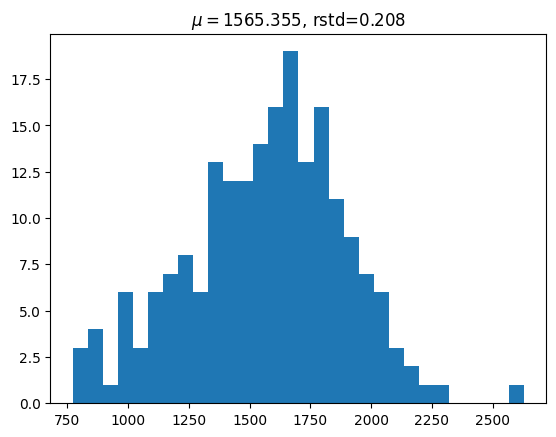

In [9]:
n = 4
for m in ms[ms>n+1]:
    fig, ax = plt.subplots()
    collapses = torch.tensor(stats[(n, m.item())])
    ax.hist(stats[(n, m.item())], bins=30)
    collapses = collapses.to(float)
    ax.set_title(f"{r'$\mu=$'}{collapses.mean().item():.3f}, rstd={(collapses.std()/collapses.mean()).item():.3f}")
plt.show()